CREATING INPUT-TARGET PAIRS


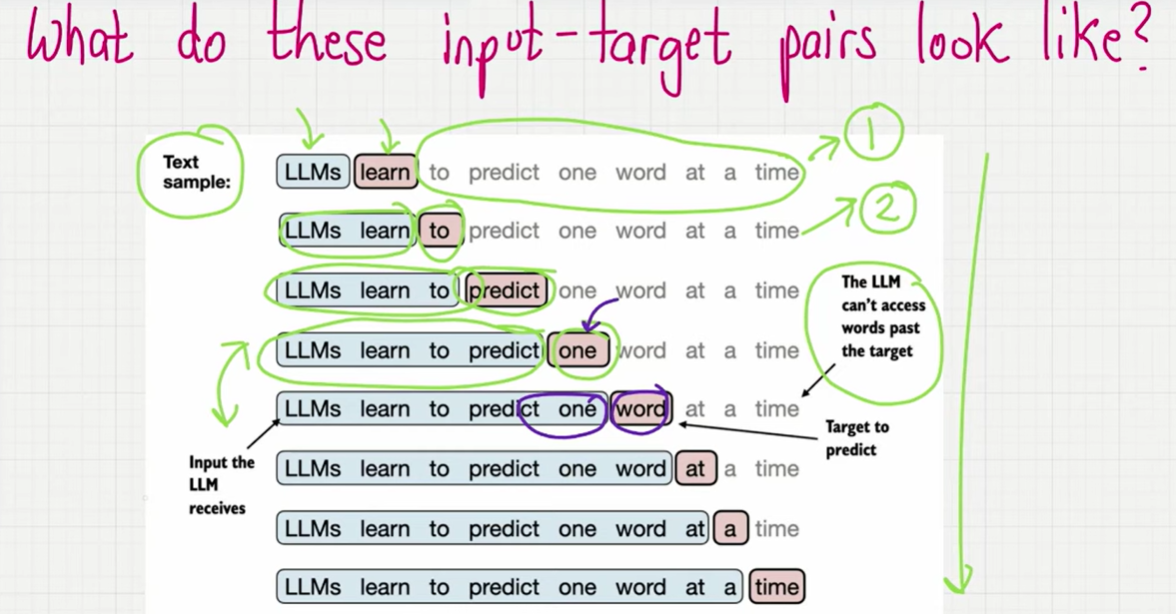

Below we implement a data loader that fetches the input-target pairs using a ***sliding window approach***.

We will first tokenize the whole *The Verdict * short story we worked with earlier using the BPE tokenizer.

In [33]:
import re
with open(r'The_Verdict.txt', 'r', encoding="utf-8", errors='ignore') as f:
    raw_text = f.read()

preprocessed = re.split(r'([!@#$%^&*_\[\]\-+=:;",<>/?.|{}\s]'')', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])
print(len(preprocessed))

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '-', 'though', 'a', 'good', 'fellow', 'enough', '-', '-', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',']
4859


In [34]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer, token in enumerate(all_tokens)}
print(len(vocab))

1252


In [35]:
class SimpleTokenizerV2:
  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {i:s for s,i in vocab.items()}

  def encode(self, text):

    preprocessed = re.split(r'(\s+|[.,!?;()"-])',text)
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    preprocessed = [item if item in self.str_to_int else "<|unk|>" for item in preprocessed]
    ids = [self.str_to_int[i] for i in preprocessed]
    return ids

  def decode(self, ids):
    text = " ".join([self.int_to_str[i] for i in ids])

    text = re.sub(r'\s+([.,!?;)"\-])', r'\1', text)
    text = re.sub(r'\s+([.,!?;)"\-])', r'\1', text)
    text = re.sub(r'(["()])\s*', r'\1', text)
    return text

In [36]:
tokenizer= SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text3 = " <|endoftext|> ".join((text1, text2))
print(text3)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [37]:
print("Total number of characters:", len(raw_text))
enc_text = tokenizer.encode(raw_text)
print(len(enc_text)) # Returns the total number of tokens after applying BPE (4808)

Total number of characters: 21458
4808


We can try removing the first 50 tokens from the dataset for demonstration as it results in a slightly more interesting text passage in the next steps->

In [38]:
enc_sample = enc_text[50:]

From here one of the esiest and most intuitive ways to create the input-target pairs for the nextword prediction task is to create two variables x and y, where x contains the input tokens and y contains the targets, which are the inputs shifted by1:

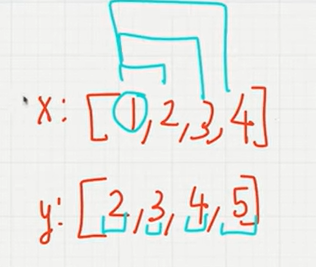

The context size determines how many tokens are included in the input

In [39]:
context_size = 4 #length of the input
#The context_size of 4 means that the model is trained to look at a sequence of 4 words (or token)
#To predict the next word in teh sequence.
#The input x is the first 4 tokens [1,2,3,4] and the target y is the next 4 tokens [2,3,4,5]

x=enc_sample[:context_size]
y=enc_sample[1:context_size+1]

print(f"x:{x}")
print(f"y:{y}")

x:[630, 654, 174, 1180]
y:[654, 174, 1180, 823]


Processing the inputs along with the targets, which are the inputs shifted by one position, we can then create the next word prediction tasks as follows:

In [40]:
for i in range(1,context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]
  print("Input","------>","Target",context, "---->",desired)

Input ------> Target [630] ----> 654
Input ------> Target [630, 654] ----> 174
Input ------> Target [630, 654, 174] ----> 1180
Input ------> Target [630, 654, 174, 1180] ----> 823


In the above the prediction size is equal to the context-size. Since context_size = 4, the prediction size above is also 4.

In [41]:
for i in range(1,context_size+1):
  context = enc_sample[:i]
  desired = enc_sample[i]
  print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

himself ----> in
himself in ----> a
himself in a ----> villa
himself in a villa ----> on


We created Input-Target pairs that we can turn into use for the LLM training in upcoming chapters.

There's only one more task before we can turn the tokens into vector embeddings:implementing an eficient data loader that iterates over the input datasets and returns the inputs and targets as PyTorch tensors, which can be thought of as multidimensional arrays.

Particularly, we are interested in returning two tensors: an input tensor containng the text that the LLM sees and a target tensor that includes the targets for the LLM to predict.

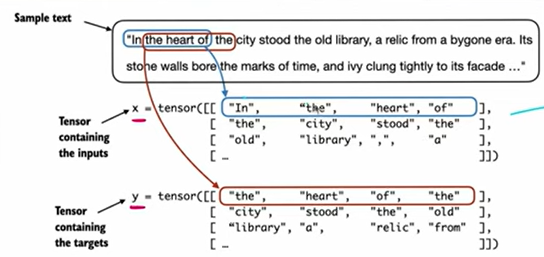

To implement efficient dataloaders, we collect inputs in a tensor x, where each row represents one input context. The second tensor y contains the corresponding prediction targets (next words), which are created by shifting the input by ne position.

# IMPLEMENTING A DATA LOADER

For efficient data loader implementation, we use PyTorch's built-in Dataset and DataLoader classes.

**Step 1:** Tokenize the entire text
    
**Step 2:** Use a sliding window to chunk the book into overlapping sequences of max_length

**Step 3:** Return the total number of rows in the dataset

**Step 4:** Return a single row from the dataset

PyTorch supports two different types of datasets:
*   Map-style datasets
*   Iterable-style datasets


# **Map-style datasets:**

---


A map-style dataset is one that implements the __getitem__() and __len__() protocols, and represents a map from (possibly non-integral) indices/keys to data samples.

For example, such a dataset, when accessed with dataset[idx], could read the idx-th image and its corresponding label from a folder on the disk.

# **Iterable-style datasets:**

---


An iterable-style dataset is an instance of a subclass of IterableDataset that implements the __iter__() protocol, and represents an iterable over data samples. This type of datasets is particularly suitable for cases where random reads are expensive or even improbable, and where the batch size depends on the fetched data.

For example, such a dataset, when called iter(dataset), could return a stream of data reading from a database, a remote server, or even logs generated in real time.

In [46]:
from torch.utils.data import Dataset, DataLoader
class GPTDatasetV1(Dataset): #Note that the Dataset cannot be a bunch of tokens, but it should be an Input/Oupput pairs
  def __init__(self, txt, tokenizer, max_length, stride): #txt= text file, tokenizer= BPE, max_length= context_size, stride= next set of input chunks ie[the, city, stood, the]
    self.input_ids = []
    self.target_ids = []

    # Tokenize the entire text
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    #Use a sliding wwindow to chunk the book into overlapping sequences of max_length
    for i in range(0, len(token_ids)-max_length, stride):
      input_chunk = token_ids[i:i+max_length]
      target_chunk = token_ids[i+1:i+max_length+1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

#
  def __len__(self):
    return len(self.input_ids)

#Below idx is index. here we tell that if the idx is 50 then the input will be the 50th row of the input tensor and the target will be the 50th row of the output tensor
#The __get_item__() is finally what the data loader will be using.
  def __getitem__(self,idx):
    return self.input_ids[idx], self.target_ids[idx]

Now we wwill use the GPTDatasetV1 to load teh inputs in batches via a PyTorch DataLoader:

**Step 1:** Initialize the tokenizer

**Step 2:** Create dataset

**Step 3:** drop_last=True drops the last batch if it is shorter than the specified batch_size to prevent loss spikes
during training

**Step 4:** The number of CPU processes to use for preprocessing

In [43]:
import tiktoken
#The below function will implement the :batch processing" or "parallel processing" that we need.
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):
  #txt=textfiles, batch_size= no of CPU processes to be run, max_lenght= context_length(default-256), stride= when we create a I/O batch how much we want to skip before the next batch is stride, num_workers= No of CPU threads that we can run simultaneously

  #Initialize the tokenizer
  tokenizer = tiktoken.get_encoding("gpt2") #tiktoken- is the BPE used by gpt

  #Create dataset
  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  #Create dataloader
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                          drop_last = drop_last, num_workers=num_workers)
  return dataloader

Now I test the dataloadder with a batch size of 1 for an LLm with a context size of 4,

This will develop an intuition of how the GPTDatasetV1 class and the create_dataloader_v1 function work together:

In [44]:
with open("The_Verdict.txt", "r", encoding="utf-8", errors='ignore') as f:
  raw_text = f.read()

Convert dataloader into a Python iterator to fetch the next entry via Python's built-in next() function

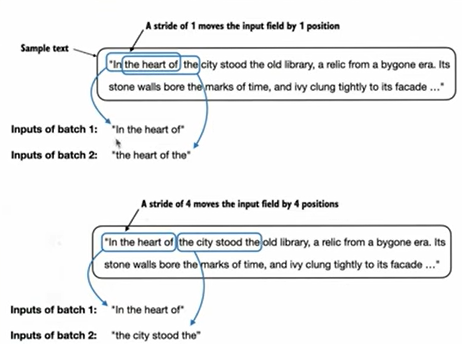

This is how stride works when stride=1 and when stride=4.

In [49]:
import torch
print("PyTorch version:", torch.__version__)
dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle= False)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print("Input Tensor","---->", "Output Tensor")
print(first_batch)

PyTorch version: 2.9.0+cpu
Input Tensor ----> Output Tensor
[tensor([[ 198,   40,  367, 2885]]), tensor([[  40,  367, 2885, 1464]])]


The first_batch variable contains two tensors: the first tensor stores the input token IDs,
and the second tensor stores the target token IDs.

Since the max_length is set to 4, each of the two tensors contains 4 token IDs.

Note that an input size of 4 is relatively small and only chosen for illustration purposes. It is common to train LLMs with input sizes of at least
256.

In [50]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


If we compare the first with the second batch, we can see that the second batch's token
IDs are shifted by one position compared to the first batch.

For example, the second ID in
the first batch's input is 367, which is the first ID of the second batch's input.

The stride
setting dictates the number of positions the inputs shift across batches, emulating a sliding
window approach

Batch sizes of 1, such as we have sampled from the data loader so far, are useful for
illustration purposes.
                                                                                 
If you have previous experience with deep learning, you may know
that small batch sizes require less memory during training but lead to more noisy model
updates.

Just like in regular deep learning, the batch size is a trade-off and hyperparameter
to experiment with when training LLMs.

***Before we move on to the two final sections of this chapter that are focused on creating
the embedding vectors from the token IDs, let's have a brief look at how we can use the
data loader to sample with a batch size greater than 1:***

In [52]:
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=4, stride=4, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)
print("Inputs:\n", inputs)
print("Targets:\n", targets)

Inputs:
 tensor([[  198,    40,   367,  2885],
        [ 1464,  1807,  3619,   402],
        [  271, 10899,  2138,   257],
        [ 7026, 15632,    12,  2016],
        [  257,   922,  5891,  1576],
        [  438,   568,   340,   373],
        [  645,  1049,  5975,   284],
        [  502,   284,  3285,   326]])
Targets:
 tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,    12,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])


Here, more the stride less will be the overfitting thus reducing the noise, but takes long duration to process as it has to process through a whole chunk of text. Lesser the stride there will be more overlap between the inputs of subsequent batches and can lead to overfitting and hence high noise but less duration

**Note:** If Stride length = context length then there is no overfitting and also there is no scenario of missing any words.